# Fine-tuning RoBERTa for sentiment analysis

**Input:** `train.csv`, `val.csv`, `test.csv` from the baseline notebook (the same splits, so the comparison with TF-IDF is fair)
**Goal:** fine-tune a pretrained transformer on the 3-class problem and compare it with the TF-IDF + Logistic Regression baseline.

**Steps**
1. Setup and device check
2. Load the splits
3. Tokenize
4. Class weights
5. Train
6. Evaluate once on the test set
7. Compare with the baseline
8. Where does RoBERTa help? (error analysis)
9. Save the model and predictions

> **Hardware:** this needs a GPU. On a free Colab GPU (T4), 3 epochs on about 24,000 short reviews takes roughly 10-20 minutes. On a CPU it would take hours, so use a smaller model (see the `MODEL_NAME` note below) or Colab.

## 1. Setup

Uncomment the install line if the libraries are missing. In Colab, `torch` is already installed.

In [1]:
# !pip install -q transformers accelerate scikit-learn

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, Trainer, TrainingArguments, set_seed)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "no GPU found")

Device: cuda | Tesla T4


### Settings

Everything you might want to change is in this one cell.

- **`MODEL_NAME`**: `roberta-base` is my recommendation. If training is too slow, switch to `distilbert-base-uncased` (about 40% smaller and faster, usually a point or two behind).
- **`MAX_LENGTH`**: 128 tokens covers about 95% of reviews (the cleaning notebook showed a 95th percentile of 84 words).
- **`BATCH_SIZE`**: lower it to 16 if the GPU runs out of memory.
- **`WEIGHT_POWER`**: see section 4.

In [31]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/Ironhack_Shared/Workshops/NLP_Customer_Reviews/data"   # adjust to what ls shows


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
MODEL_NAME = "roberta-base"
MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_POWER = 0.5
            # folder containing train.csv, val.csv, test.csv
OUTPUT_DIR = "roberta_sentiment"
LABELS = ["negative", "neutral", "positive"]   # label ids 0, 1, 2


from pathlib import Path
print([p.name for p in Path(DATA_DIR).glob("*.csv")])   # should list train.csv, val.csv, test.csv

from pathlib import Path

d = Path(DATA_DIR)
print("Folder exists:", d.exists())
print("Contents:", [p.name for p in d.iterdir()] if d.exists() else "n/a")

# search the parent project folder (and everything below it) for the splits
for p in d.parent.rglob("train.csv"):
    print("Found:", p)

['1429_1.csv', 'reviews_clean.csv', '1429_1_R.csv', 'train.csv', 'val.csv', 'test.csv']
Folder exists: True
Contents: ['1429_1.csv.zip', '1429_1.csv', 'reviews_clean.csv', '1429_1_R.csv', 'train.csv', 'val.csv', 'test.csv']
Found: /content/drive/MyDrive/Ironhack_Shared/Workshops/NLP_Customer_Reviews/data/train.csv


## 2. Load the splits

In [33]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
val_df = pd.read_csv(f"{DATA_DIR}/val.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s} n={len(part):6d}", part["sentiment"].value_counts().reindex(LABELS).tolist())

train n= 24217 [567, 1049, 22601]
val   n=  5190 [121, 225, 4844]
test  n=  5190 [122, 225, 4843]


## 3. Tokenize

A transformer doesn't read words, it reads **tokens** (word pieces) turned into numbers. We use the tokenizer that belongs to the chosen model, and cut reviews at `MAX_LENGTH` tokens.

We do **not** pad everything to the full length here. A `DataCollatorWithPadding` pads each batch only to its longest review, which is faster because most reviews are short. We also keep case and punctuation as they are, since RoBERTa was trained on raw text.

In [34]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.enc = tokenizer(df["text"].tolist(), truncation=True, max_length=MAX_LENGTH)
        self.labels = df["label"].tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

train_ds, val_ds, test_ds = ReviewDataset(train_df), ReviewDataset(val_df), ReviewDataset(test_df)
collator = DataCollatorWithPadding(tokenizer)

# How many reviews are actually cut off?
lengths = [len(x) for x in train_ds.enc["input_ids"]]
print("Reviews hitting the length limit:", f"{np.mean(np.array(lengths) >= MAX_LENGTH):.1%}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Reviews hitting the length limit: 2.8%


## 4. Class weights

Only 2.3% of reviews are negative and 4.3% neutral. Without a correction the model can get low loss by almost always saying "positive". Class weights make mistakes on rare classes count more in the loss.

Fully "balanced" weights are very strong (the negative class would count about 40 times more than positive). That often makes the model over-predict the rare classes and hurts precision. So we use the **square root** of the balanced weights (`WEIGHT_POWER = 0.5`) as a gentler compromise. Set `WEIGHT_POWER = 1.0` for fully balanced weights, or `0` for none, and compare on the validation set.

In [35]:
balanced = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=train_df["label"])
weights = balanced ** WEIGHT_POWER
print("Fully balanced:", balanced.round(2))
print("Weights used:  ", weights.round(2))
class_weights = torch.tensor(weights, dtype=torch.float)

Fully balanced: [14.24  7.7   0.36]
Weights used:   [3.77 2.77 0.6 ]


## 5. Train

We add a classification layer on top of pretrained RoBERTa and train the whole network end to end.

- **Learning rate 2e-5** with warm-up and linear decay: transformers need small learning rates, because large ones destroy what the model already knows.
- **3 epochs**: usually enough. More tends to overfit on this much data.
- **Model selection:** after each epoch we score the validation set, and at the end we keep the checkpoint with the best **validation macro-F1**, not the last one.
- The test set is not used anywhere in this section.

In [38]:
import math
import numpy as np
from torch import nn
from sklearn.metrics import accuracy_score, f1_score
from transformers import (AutoModelForSequenceClassification, Trainer, TrainingArguments)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro")}


class WeightedTrainer(Trainer):
    # Same as Trainer, but the loss uses our class weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(outputs.logits.device))
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3,
    id2label=dict(enumerate(LABELS)), label2id={l: i for i, l in enumerate(LABELS)})

steps_per_epoch = math.ceil(len(train_ds) / BATCH_SIZE)
warmup_steps = int(0.1 * EPOCHS * steps_per_epoch)   # 10% of training
print("Warm-up steps:", warmup_steps)

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
    logging_steps=100,
)

trainer = WeightedTrainer(
    model=model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=collator, compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Warm-up steps: 227


In [39]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.441556,0.473721,0.904239,0.602228
2,0.318036,0.467453,0.941040,0.682182
3,0.275412,0.575781,0.946050,0.687145


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2271, training_loss=0.38245325075902903, metrics={'train_runtime': 434.8241, 'train_samples_per_second': 167.081, 'train_steps_per_second': 5.223, 'total_flos': 4364634832564986.0, 'train_loss': 0.38245325075902903, 'epoch': 3.0})

After training, check the learning curves. If the training loss keeps falling while the validation loss goes up, the model is overfitting.

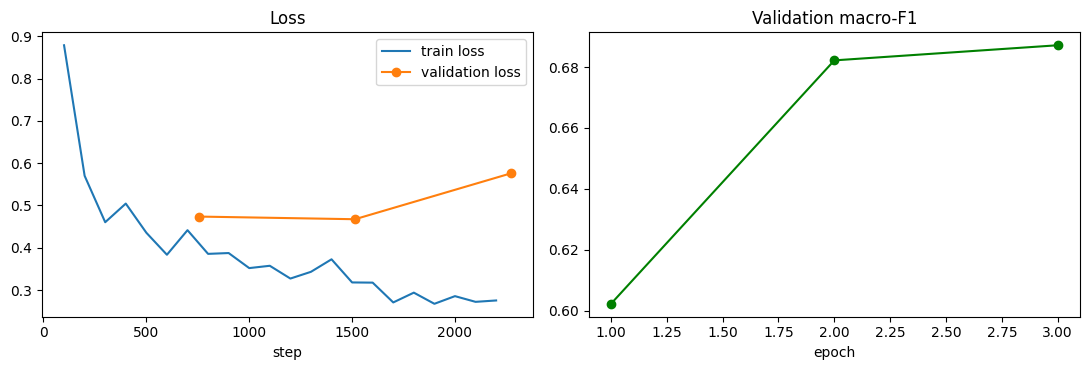

In [40]:
log = pd.DataFrame(trainer.state.log_history)
train_loss = log.dropna(subset=["loss"])
eval_log = log.dropna(subset=["eval_loss"])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(train_loss["step"], train_loss["loss"], label="train loss")
ax[0].plot(eval_log["step"], eval_log["eval_loss"], "o-", label="validation loss")
ax[0].set_xlabel("step"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(eval_log["epoch"], eval_log["eval_macro_f1"], "o-", color="green")
ax[1].set_xlabel("epoch"); ax[1].set_title("Validation macro-F1")
plt.tight_layout(); plt.show()

## 6. Final evaluation on the test set

As with the baseline, this is the one time we look at the test set.

In [41]:
out = trainer.predict(test_ds)
y_test = test_df["label"].values
y_pred = out.predictions.argmax(axis=-1)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"Test macro-F1: {f1_score(y_test, y_pred, average='macro'):.3f}\n")
print(classification_report(y_test, y_pred, target_names=LABELS, digits=3))

Test accuracy: 94.6%
Test macro-F1: 0.709

              precision    recall  f1-score   support

    negative      0.698     0.738     0.717       122
     neutral      0.426     0.444     0.435       225
    positive      0.978     0.974     0.976      4843

    accuracy                          0.946      5190
   macro avg      0.700     0.719     0.709      5190
weighted avg      0.947     0.946     0.947      5190



               pred negative  pred neutral  pred positive
true negative             90            23              9
true neutral              27           100             98
true positive             12           112           4719


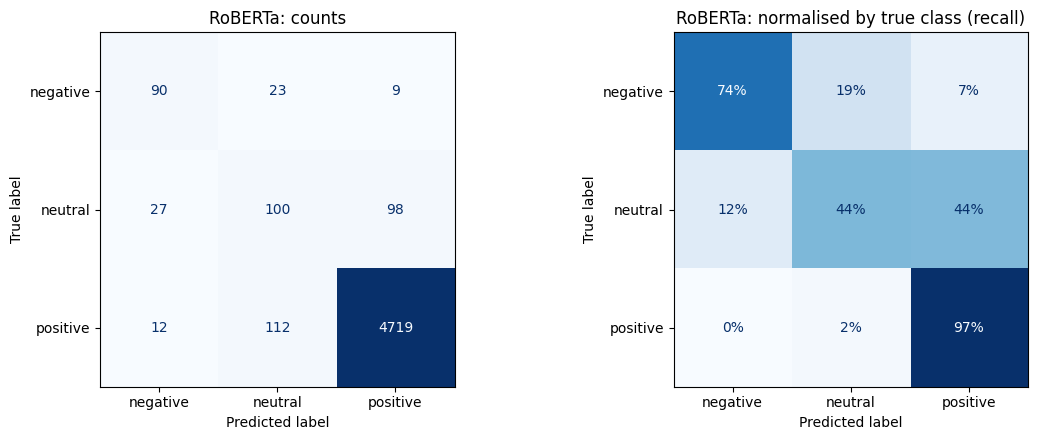

In [42]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=[f"true {l}" for l in LABELS],
                   columns=[f"pred {l}" for l in LABELS]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=LABELS, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("RoBERTa: counts")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=LABELS, cmap="Blues", normalize="true",
    values_format=".0%", ax=axes[1], colorbar=False)
axes[1].set_title("RoBERTa: normalised by true class (recall)")
plt.tight_layout(); plt.show()

## 7. Compare with the TF-IDF baseline

To compare on exactly the same test reviews, we refit the baseline here with the settings that won on validation in the baseline notebook (word pairs, `C = 10`). It takes under a minute.

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True,
                              strip_accents="unicode")),
    ("clf", LogisticRegression(C=10, class_weight="balanced", max_iter=1000, random_state=SEED)),
]).fit(train_df["text"], train_df["label"])
base_pred = baseline.predict(test_df["text"])

def summary(name, y_true, y_hat):
    f1s = f1_score(y_true, y_hat, average=None, labels=[0, 1, 2])
    return {"model": name,
            "accuracy": accuracy_score(y_true, y_hat),
            "macro_f1": f1_score(y_true, y_hat, average="macro"),
            "negative_f1": f1s[0], "neutral_f1": f1s[1], "positive_f1": f1s[2]}

comparison = pd.DataFrame([summary("TF-IDF + LR", y_test, base_pred),
                           summary(MODEL_NAME, y_test, y_pred)]).set_index("model")
comparison.round(3)

,accuracy,macro_f1,negative_f1,neutral_f1,positive_f1
model,,,,,
TF-IDF + LR,0.936,0.654,0.608,0.385,0.969
roberta-base,0.946,0.709,0.717,0.435,0.976


**Reading the table:** accuracy will look similar for both models, because 93% of the data is positive. Look at **macro-F1** and especially the **neutral F1**, which is where the models differ most.

Remember that the test set has only about 120 negative and 225 neutral reviews. A difference of a couple of F1 points on those classes can be chance. Differences of five or more points are more convincing.

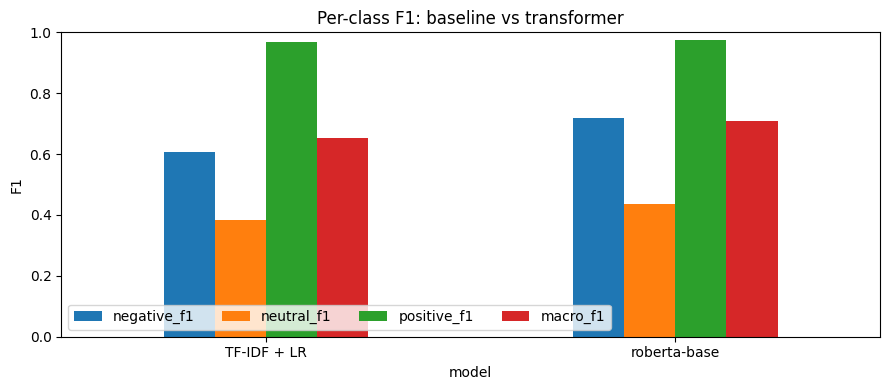

In [44]:
comparison[["negative_f1", "neutral_f1", "positive_f1", "macro_f1"]].plot(
    kind="bar", figsize=(9, 4), rot=0, ylim=(0, 1))
plt.title("Per-class F1: baseline vs transformer")
plt.ylabel("F1"); plt.legend(loc="lower left", ncol=4)
plt.tight_layout(); plt.show()

## 8. Where does the transformer help?

We split the test reviews by who got them right. Reviews where **RoBERTa is right and the baseline is wrong** show what the transformer understands that bag-of-words does not (negation, context, sarcasm). Reviews where **both are wrong** are likely ambiguous or mislabelled.

In [45]:
res = test_df.assign(roberta=y_pred, baseline=base_pred)
res["rob_ok"] = res["roberta"] == res["label"]
res["base_ok"] = res["baseline"] == res["label"]

print("Both right:           ", (res.rob_ok & res.base_ok).sum())
print("Only RoBERTa right:   ", (res.rob_ok & ~res.base_ok).sum())
print("Only baseline right:  ", (~res.rob_ok & res.base_ok).sum())
print("Both wrong:           ", (~res.rob_ok & ~res.base_ok).sum())

def show(mask, title, n=4):
    sub = res[mask]
    print(f"\n=== {title} ({len(sub)}) ===")
    for _, r in sub.sample(min(n, len(sub)), random_state=SEED).iterrows():
        print(f"[{r['rating']} stars | true {r['sentiment']} | RoBERTa {LABELS[r['roberta']]} "
              f"| TF-IDF {LABELS[r['baseline']]}]\n{r['text'][:280]}\n")

show(res.rob_ok & ~res.base_ok, "Only RoBERTa right")
show(~res.rob_ok & ~res.base_ok, "Both wrong")

Both right:            4759
Only RoBERTa right:    150
Only baseline right:   97
Both wrong:            184

=== Only RoBERTa right (150) ===
[3 stars | true neutral | RoBERTa neutral | TF-IDF positive]
Is good for a first tablet. At first I thought is was going to be great because of all the apps it had. Late I discover that all of those great apps I felt in love with needed to be purchased and pay a membership. Even though it was good for a first time tablet

[3 stars | true neutral | RoBERTa neutral | TF-IDF positive]
OK TABLET MAJOR SHORTFALL. restricts use of some web pages- including barnes and nobles where I have a library- useless to read the books in my Barnes library

[4 stars | true positive | RoBERTa positive | TF-IDF neutral]
Great for a starter tablet. Good for the kids or the adult who just needs something for travel

[3 stars | true neutral | RoBERTa neutral | TF-IDF positive]
Would love to try using: can't get webroot install. I can't use until I can get the webroot in

Things worth writing about in your results:
- Which classes improved, and which did not. Neutral is usually still the hardest, because 3-star reviews are subjective.
- Whether the "both wrong" reviews look like label noise (a positive text with a low rating, or the reverse). If so, that is a ceiling on any model, not a failure of this one.
- The cost: RoBERTa needs a GPU and takes minutes to train, while TF-IDF trains in seconds on a CPU. Whether the gain is worth it depends on the gap in the table above.

## 9. Save the model and predictions

In [46]:
trainer.save_model(f"{OUTPUT_DIR}/best")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/best")

res[["text", "rating", "sentiment", "label", "roberta", "baseline"]].to_csv(
    "test_predictions.csv", index=False)
print("Saved model to", f"{OUTPUT_DIR}/best", "and predictions to test_predictions.csv")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to roberta_sentiment/best and predictions to test_predictions.csv


To use the model later on new reviews:

```python
from transformers import pipeline
clf = pipeline("text-classification", model="roberta_sentiment/best")
clf("The battery died after two weeks and support never answered.")
```

## Summary

| Model | Accuracy | Macro-F1 | Negative F1 | Neutral F1 | Positive F1 |
|---|---|---|---|---|---|
| Always positive | 93.3% | 0.32 | 0 | 0 | 0.97 |
| TF-IDF + LR | 93.6% | 0.65 | 0.61 | 0.39 | 0.97 |
| RoBERTa | see section 7 | | | | |

**Next steps if you want to go further:** try other label mappings (for example, dropping neutral to get a binary problem, or predicting 5 classes), compare `WEIGHT_POWER` values, and try the `distilbert-base-uncased` and `cardiffnlp/twitter-roberta-base-sentiment` models for a wider comparison.

In [47]:
import shutil
DRIVE_OUT = "/content/drive/MyDrive/Ironhack_Shared/Workshops/NLP_Customer_Reviews/data"   # any Drive folder you like
shutil.copytree(f"{OUTPUT_DIR}/best", f"{DRIVE_OUT}/roberta_best", dirs_exist_ok=True)
shutil.copy("test_predictions.csv", DRIVE_OUT)

'/content/drive/MyDrive/Ironhack_Shared/Workshops/NLP_Customer_Reviews/data/test_predictions.csv'